# Prediksi Harga Rumah California — Proyek Data Mining (CRISP-DM)
## Kelompok 5

**Anggota Kelompok:**

- Alya Salma Khoerunnisaa - 102022430027
- Maurellio Christopher Yonathan - 102022430009
- Jazzkord Cmajor Dahring - 102022400361
- Cantika Nurul Fitri - 1202220080

---

Notebook ini disusun mengikuti **6 tahap metodologi CRISP-DM** (Cross-Industry Standard
Process for Data Mining):

1. **Business Understanding** — memahami tujuan bisnis & merumuskan masalah.
2. **Data Understanding** — mengenal data, statistik, dan EDA.
3. **Data Preparation** — pembersihan, *feature engineering*, encoding, scaling.
4. **Modeling** — *best-model search*: membandingkan banyak model + tuning (GridSearchCV).
5. **Evaluation** — evaluasi mendalam model terbaik (visual & metrik).
6. **Deployment** — menyimpan model & contoh inferensi untuk dipakai ulang.



In [1]:
# 1. LIBRARY DASAR & CONFIGURATION
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor,
                              RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, roc_auc_score)

try:
    from xgboost import XGBRegressor, XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False
print('XGBoost tersedia:', HAS_XGB)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

XGBoost tersedia: False


# 1. Business Understanding

**Latar belakang.** Harga rumah di California sangat bervariasi tergantung lokasi, kondisi
ekonomi penduduk, dan karakteristik bangunan. Memahami pola ini berguna bagi agen properti,
investor, dan pemerintah daerah untuk pengambilan keputusan.

**Rumusan masalah & tujuan analitik:**

| Task | Tujuan | Target | Metrik sukses |
|------|--------|--------|---------------|
| **Regresi** | Memprediksi nilai rumah | `median_house_value` (kontinu) | RMSE rendah, R² tinggi |
| **Klasifikasi** | Menentukan rumah mahal/murah | rumah di atas/bawah median harga | F1 & Accuracy tinggi |
| **Klastering** | Segmentasi wilayah | (unsupervised) | Silhouette score tertinggi |

**Kriteria keberhasilan:** model terbaik harus mengungguli baseline awal
(Linear Regression R²≈0.58; Random Forest accuracy≈0.89).


# 2. Data Understanding

Dataset **California Housing** (sensus 1990), 20.640 baris × 10 kolom. Kita muat dari berkas
lokal `housing.csv`.


In [2]:
df = pd.read_csv('housing.csv')
print('Dimensi data:', df.shape)
df.head()

Dimensi data: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Ringkasan tipe data tiap variabel
data_info = pd.DataFrame({
    'Nama Variabel': df.columns,
    'Tipe Data': df.dtypes.astype(str).values,
    'Jumlah Non-Null': df.notnull().sum().values,
    'Jumlah Unik': [df[c].nunique() for c in df.columns]
})
data_info


,Nama Variabel,Tipe Data,Jumlah Non-Null,Jumlah Unik
0,longitude,float64,20640,844
1,latitude,float64,20640,862
2,housing_median_age,float64,20640,52
3,total_rooms,float64,20640,5926
4,total_bedrooms,float64,20433,1923
5,population,float64,20640,3888
6,households,float64,20640,1815
7,median_income,float64,20640,12928
8,median_house_value,float64,20640,3842
9,ocean_proximity,object,20640,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
# Ringkasan missing value
missing = df.isnull().sum()
missing = missing[missing > 0].rename('Jumlah Missing').to_frame()
missing['Persen (%)'] = (missing['Jumlah Missing'] / len(df) * 100).round(2)
print('Kolom dengan missing value:')
missing


Kolom dengan missing value:


,Jumlah Missing,Persen (%)
total_bedrooms,207,1.0


## 2.1 Exploratory Data Analysis (EDA)

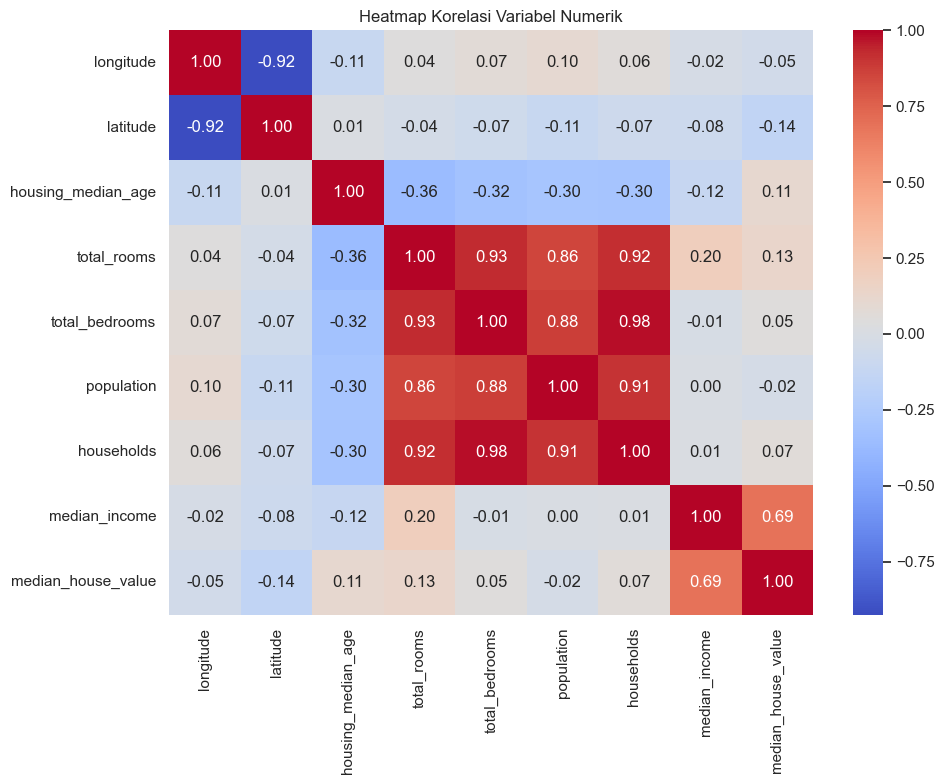

In [7]:
# Korelasi antar variabel numerik
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Variabel Numerik')
plt.tight_layout(); plt.show()


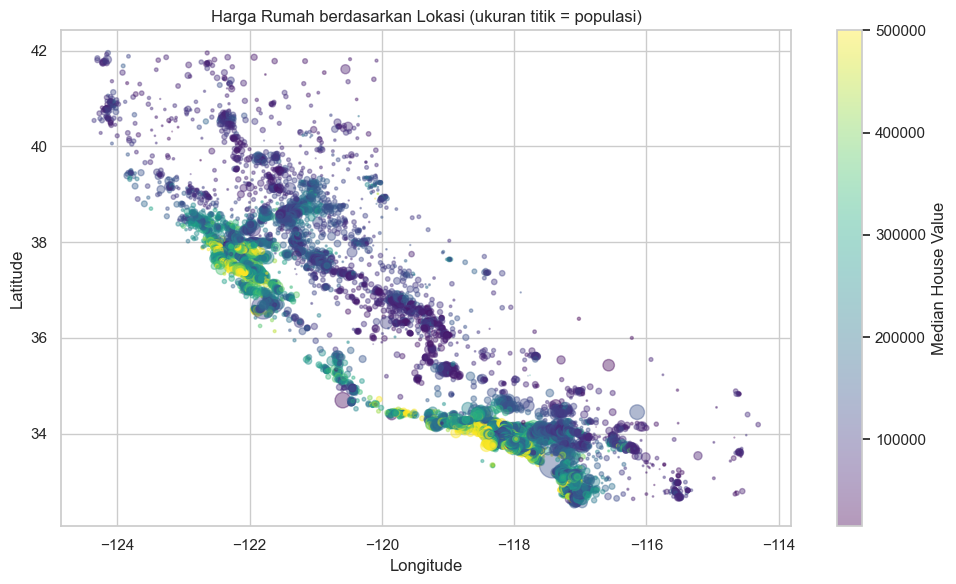

In [8]:
# Sebaran harga rumah berdasarkan lokasi geografis
plt.figure(figsize=(10, 6))
sc = plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'],
                 cmap='viridis', s=df['population']/100, alpha=0.4)
plt.colorbar(sc, label='Median House Value')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('Harga Rumah berdasarkan Lokasi (ukuran titik = populasi)')
plt.tight_layout(); plt.show()


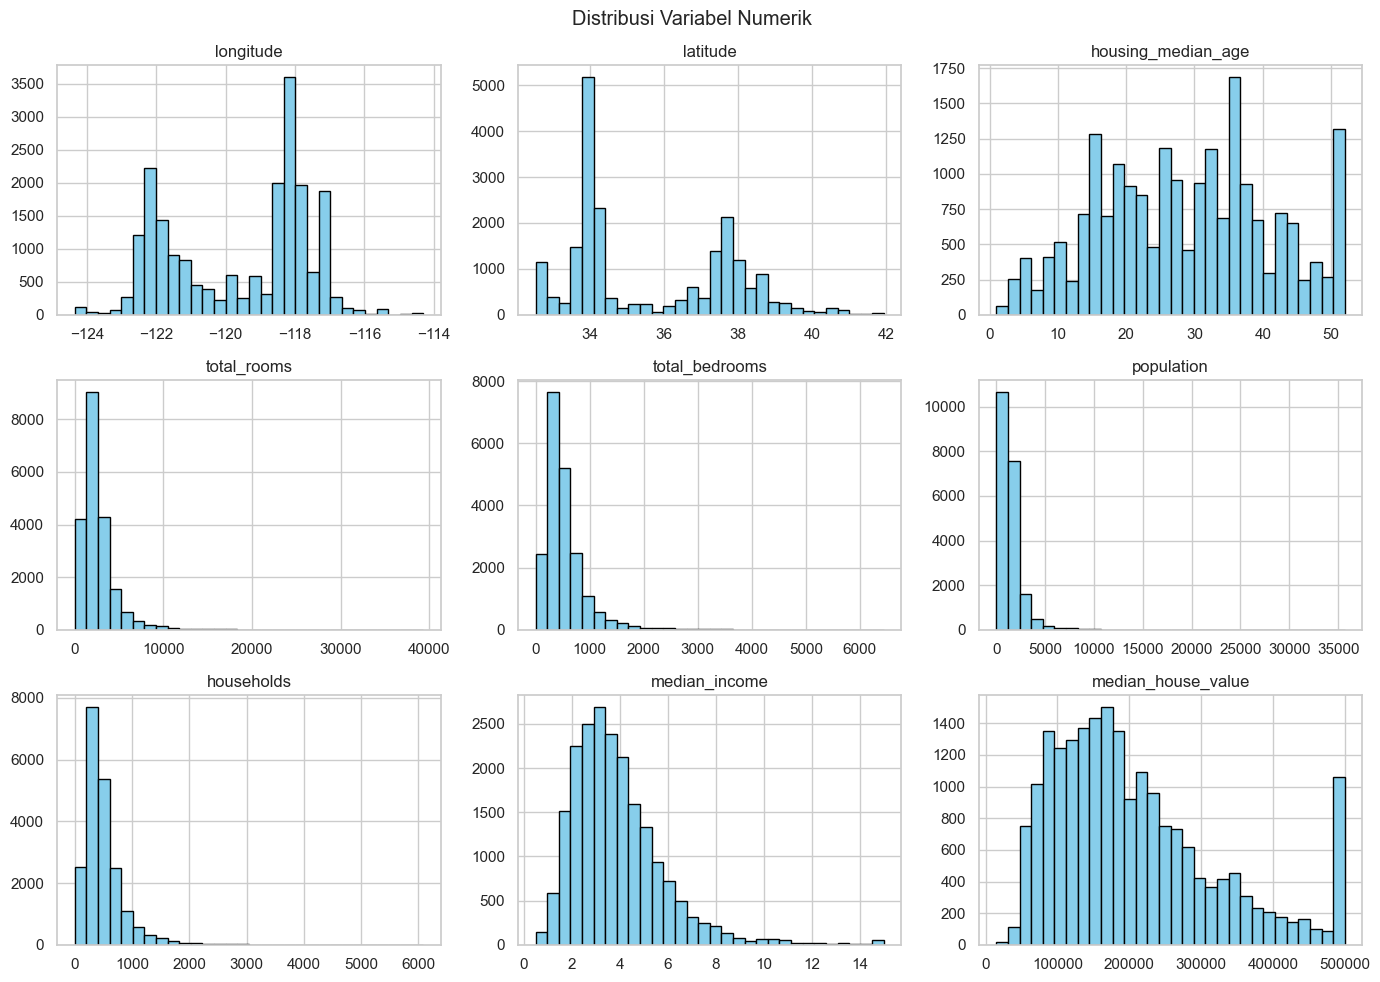

In [9]:
# Histogram seluruh variabel numerik
df.select_dtypes(include=[np.number]).hist(bins=30, figsize=(14, 10), color='skyblue', edgecolor='black')
plt.suptitle('Distribusi Variabel Numerik')
plt.tight_layout(); plt.show()


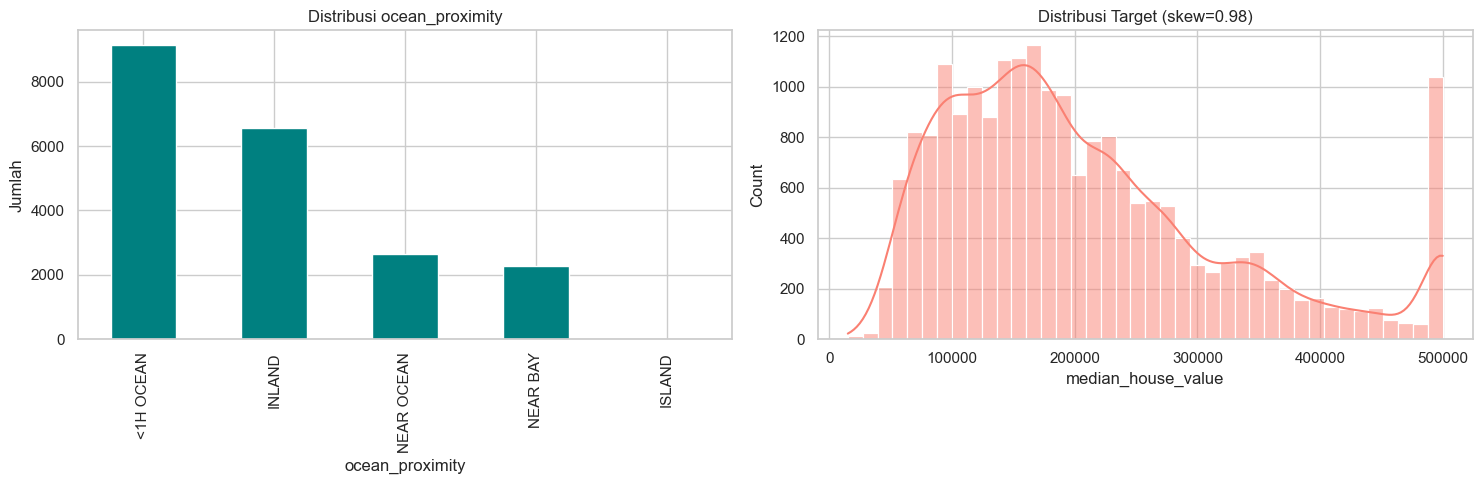

In [10]:
# Distribusi kategori ocean_proximity & distribusi target
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
df['ocean_proximity'].value_counts().plot(kind='bar', ax=ax[0], color='teal')
ax[0].set_title('Distribusi ocean_proximity'); ax[0].set_ylabel('Jumlah')
sns.histplot(df['median_house_value'], bins=40, kde=True, ax=ax[1], color='salmon')
ax[1].set_title(f"Distribusi Target (skew={df['median_house_value'].skew():.2f})")
plt.tight_layout(); plt.show()


# 3. Data Preparation

Langkah: (1) imputasi missing value, (2) **feature engineering**, (3) one-hot encoding
`ocean_proximity`, (4) definisi fitur & target, (5) scaling (disimpan untuk deployment).


In [11]:
# 1. Pisahkan fitur dan target awal
X_raw = df.drop(columns=['median_house_value'])
y_reg = df['median_house_value']

valid_idx = y_reg < 500000
X_raw = X_raw[valid_idx]
y_reg = y_reg[valid_idx]

# 2. Train-Test Split
X_train, X_test, yr_train, yr_test = train_test_split(X_raw, y_reg, test_size=0.2, random_state=RANDOM_STATE)

X_train = X_train.copy()
X_test = X_test.copy()

In [12]:
# 3. Imputasi & Feature Engineering pada Train dan Test
median_bedrooms = X_train['total_bedrooms'].median()

for data in [X_train, X_test]:
    data['total_bedrooms'] = data['total_bedrooms'].fillna(median_bedrooms)
    data['rooms_per_household'] = data['total_rooms'] / data['households']
    data['bedrooms_per_room'] = data['total_bedrooms'] / data['total_rooms']
    data['population_per_household'] = data['population'] / data['households']

print("Statistik Fitur Baru (Data Latih):")
print(X_train[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe())

Statistik Fitur Baru (Data Latih):
       rooms_per_household  bedrooms_per_room  population_per_household
count         15718.000000       15718.000000              15718.000000
mean              5.369115           0.215520                  3.128386
std               2.377806           0.064865                 11.880175
min               0.846154           0.037236                  0.692308
25%               4.426840           0.177240                  2.450413
50%               5.185730           0.204259                  2.837691
75%               5.974703           0.240830                  3.305015
max             132.533333           2.831169               1243.333333


In [13]:
# One-hot encoding dengan drop_first=True
X_train = pd.get_dummies(X_train, columns=['ocean_proximity'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['ocean_proximity'], drop_first=True)

# Memastikan jumlah dan urutan kolom X_train dan X_test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [14]:
# 4. Klasterisasi berbasis spasial & ekonomi
clust_features = ['longitude', 'latitude', 'median_income', 'housing_median_age']
scaler_clust = StandardScaler()

Xc_train_scaled = scaler_clust.fit_transform(X_train[clust_features])
Xc_test_scaled = scaler_clust.transform(X_test[clust_features])

kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
X_train['cluster'] = kmeans.fit_predict(Xc_train_scaled)
X_test['cluster'] = kmeans.predict(Xc_test_scaled)

print("\nData Preparation Selesai Berhasil!")
print(f"Dimensi X_train: {X_train.shape} | Dimensi X_test: {X_test.shape}")


Data Preparation Selesai Berhasil!
Dimensi X_train: (15718, 16) | Dimensi X_test: (3930, 16)


# 4. Modeling — *Best-Model Search*

Inti upgrade: alih-alih satu model, kita **membandingkan banyak kandidat** dengan
cross-validation, lalu **tuning** model terbaik memakai `GridSearchCV`.


## 4a. Klastering — mencari K terbaik (silhouette)

Loop K = 2..8, hitung *inertia* (elbow) dan *silhouette score*, pilih K dengan silhouette
tertinggi. Label klaster dijadikan fitur tambahan.


In [15]:
# 1. CARI K TERBAIK
inertia, sil = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xc_train_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xc_train_scaled, km.labels_))

best_k = list(K_range)[int(np.argmax(sil))]
print('Silhouette per K:', {k: round(s,3) for k,s in zip(K_range, sil)})
print('K terbaik secara otomatis (silhouette):', best_k)

Silhouette per K: {2: 0.408, 3: 0.331, 4: 0.313, 5: 0.306, 6: 0.313, 7: 0.303, 8: 0.302}
K terbaik secara otomatis (silhouette): 2


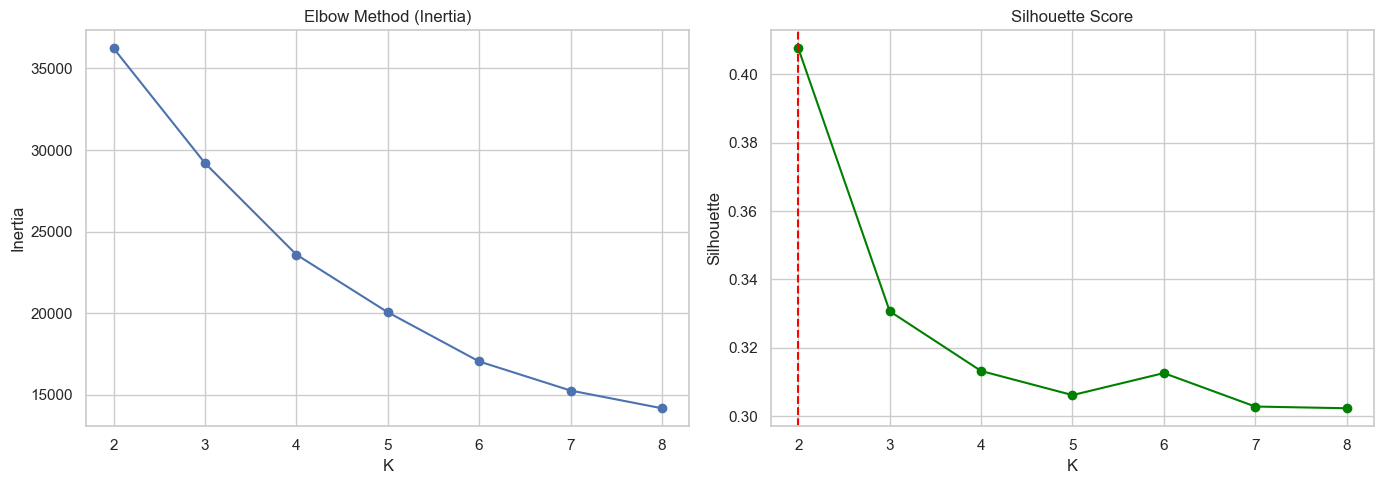

In [16]:
# 2. VISUALISASI ELBOW + SILHOUETTE
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(K_range), inertia, 'o-')
ax[0].set_title('Elbow Method (Inertia)')
ax[0].set_xlabel('K'); ax[0].set_ylabel('Inertia')

ax[1].plot(list(K_range), sil, 'o-', color='green')
ax[1].set_title('Silhouette Score')
ax[1].axvline(best_k, ls='--', color='red')
ax[1].set_xlabel('K'); ax[1].set_ylabel('Silhouette')
plt.tight_layout(); plt.show()

In [17]:
# 3. FIT K-MEANS TERBAIK & MASUKKAN SEBAGAI FITUR BARU
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)

X_train['cluster'] = kmeans.fit_predict(Xc_train_scaled)
X_test['cluster'] = kmeans.predict(Xc_test_scaled)

In [18]:
# 4. PROFILING KLASTER (MENGGUNAKAN DATA TRAINING YANG BERSIH)
train_profile = X_train.copy()
train_profile['median_house_value'] = yr_train

profiling = train_profile.groupby('cluster')[['median_income', 'housing_median_age', 'median_house_value']].mean()
print('\nDistribusi jumlah sampel per klaster pada Data Training:\n', X_train['cluster'].value_counts().sort_index())
print("\nProfil Rata-rata Tiap Klaster:")
print(profiling)


Distribusi jumlah sampel per klaster pada Data Training:
 cluster
0    6717
1    9001
Name: count, dtype: int64

Profil Rata-rata Tiap Klaster:
         median_income  housing_median_age  median_house_value
cluster                                                       
0             3.631568           28.654161       184120.648802
1             3.713708           28.283302       197972.936229


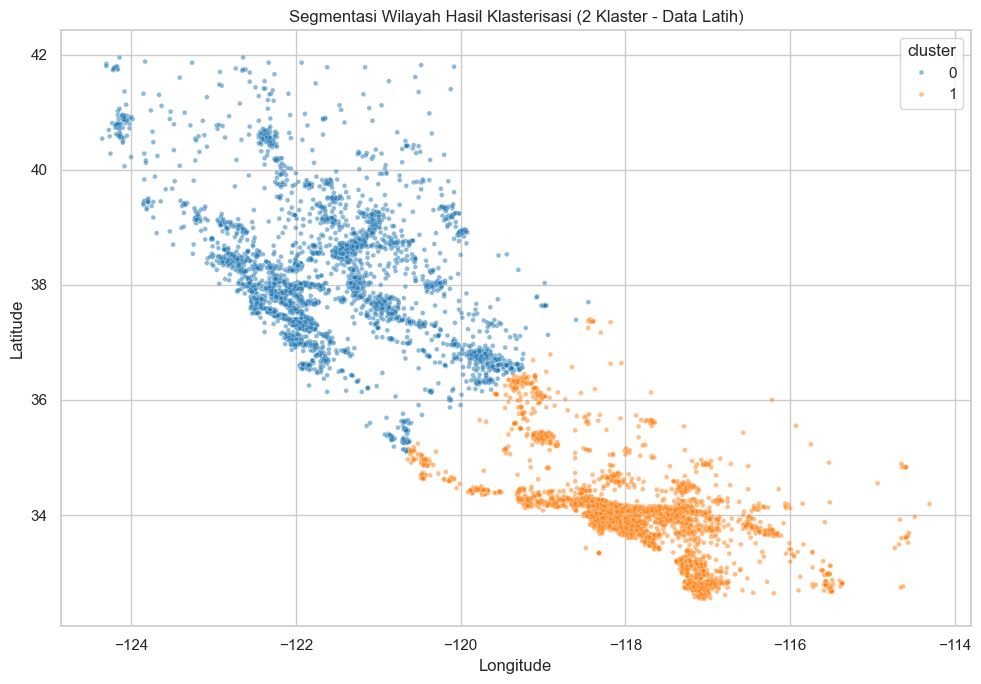

In [19]:
# 5. VISUALISASI SEBARAN KLASTER SECARA GEOGRAFIS
plt.figure(figsize=(10, 7))
sns.scatterplot(data=X_train, x='longitude', y='latitude', hue='cluster',
                palette='tab10', s=12, alpha=0.5)
plt.title(f'Segmentasi Wilayah Hasil Klasterisasi ({best_k} Klaster - Data Latih)')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.tight_layout(); plt.show()

## 4b. Regresi — bandingkan & tuning

Kandidat dibandingkan dengan 5-fold CV (RMSE). Model terbaik di-*tuning* via GridSearchCV.


In [20]:
# 1. EVALUASI DAN PERBANDINGAN MODEL KANDIDAT REGRESI
reg_candidates = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'Lasso': Lasso(random_state=RANDOM_STATE),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

if HAS_XGB:
    reg_candidates['XGBoost'] = XGBRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
reg_results = []

print('--- Memulai Proses Cross-Validation Model Kandidat ---')
for name, model in reg_candidates.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    scores = cross_val_score(pipeline, X_train, yr_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    reg_results.append({'Model': name, 'CV_RMSE': -scores.mean(), 'CV_RMSE_std': scores.std()})

reg_df = pd.DataFrame(reg_results).sort_values('CV_RMSE').reset_index(drop=True)
print('\nPerbandingan model regresi (CV RMSE):')
print(reg_df)

--- Memulai Proses Cross-Validation Model Kandidat ---

Perbandingan model regresi (CV RMSE):
                  Model       CV_RMSE  CV_RMSE_std
0  HistGradientBoosting  42105.993308   743.893350
1          RandomForest  45257.759800   903.838310
2      GradientBoosting  48021.816217   851.906152
3                 Ridge  60101.595043  1264.488885
4                 Lasso  60102.459598  1265.271246
5      LinearRegression  60102.642424  1265.027402


In [21]:
# 2. TUNING HYPERPARAMETER MODEL TERBAIK DENGAN GRIDSEARCHCV
best_reg_name = reg_df.iloc[0]['Model']
print(f'\nModel regresi terbaik berdasarkan CV: {best_reg_name}')

reg_param_grids = {
    'LinearRegression': {},
    'Ridge': {'model__alpha': [0.1, 1.0, 10.0, 100.0]},
    'Lasso': {'model__alpha': [0.01, 0.1, 1.0, 10.0]},
    'RandomForest': {'model__n_estimators': [100, 200], 'model__max_depth': [None, 20]},
    'GradientBoosting': {'model__n_estimators': [100, 200], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 4]},
    'HistGradientBoosting': {'model__learning_rate': [0.05, 0.1], 'model__max_iter': [200, 400]},
    'XGBoost': {'model__n_estimators': [200, 400], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [4, 6]},
}

grid = reg_param_grids.get(best_reg_name, {})

tuning_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', reg_candidates[best_reg_name])
])

if grid:
    print(f'--- Melakukan Hyperparameter Tuning untuk {best_reg_name} ---')
    gs = GridSearchCV(tuning_pipeline, grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(X_train, yr_train)
    
    best_regressor = gs.best_estimator_
    print('Parameter terbaik ditemukan:', gs.best_params_)
else:
    print(f'Model {best_reg_name} tidak memerlukan tuning parameter tambahan.')
    best_regressor = tuning_pipeline.fit(X_train, yr_train)


Model regresi terbaik berdasarkan CV: HistGradientBoosting
--- Melakukan Hyperparameter Tuning untuk HistGradientBoosting ---
Parameter terbaik ditemukan: {'model__learning_rate': 0.1, 'model__max_iter': 400}


## 4c. Klasifikasi — bandingkan & tuning

Kandidat dibandingkan dengan 5-fold StratifiedCV (F1). Model terbaik di-*tuning*.


In [22]:

median_target_train = yr_train.median()
yc_train = (yr_train > median_target_train).astype(int)
yc_test = (yr_test > median_target_train).astype(int)

print(f"Sinkronisasi Selesai! Ukuran X_train: {X_train.shape[0]} baris, Ukuran yc_train: {yc_train.shape[0]} baris.")

clf_candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    'SVC': SVC(probability=True, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
}

if HAS_XGB:
    clf_candidates['XGBoost'] = XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

scv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
clf_results = []

print('\n--- Memulai Proses Cross-Validation Model Kandidat ---')
for name, model in clf_candidates.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    scores = cross_val_score(pipeline, X_train, yc_train, cv=scv, scoring='f1', n_jobs=-1)
    clf_results.append({'Model': name, 'CV_F1': scores.mean(), 'CV_F1_std': scores.std()})

clf_df = pd.DataFrame(clf_results).sort_values('CV_F1', ascending=False).reset_index(drop=True)
print('\nPerbandingan model klasifikasi (CV F1, makin besar makin baik):')
print(clf_df)

best_clf_name = clf_df.iloc[0]['Model']
print(f'\nModel klasifikasi terbaik berdasarkan CV F1: {best_clf_name}')

clf_param_grids = {
    'LogisticRegression': {'model__C': [0.1, 1.0, 10.0]},
    'RandomForest': {'model__n_estimators': [100, 200], 'model__max_depth': [None, 20]},
    'GradientBoosting': {'model__n_estimators': [100, 200], 'model__learning_rate': [0.05, 0.1]},
    'HistGradientBoosting': {'model__learning_rate': [0.05, 0.1], 'model__max_iter': [200, 400]},
    'SVC': {'model__C': [1.0, 10.0], 'model__gamma': ['scale', 'auto']},
    'KNN': {'model__n_neighbors': [5, 11, 21]},
    'XGBoost': {'model__n_estimators': [200, 400], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [4, 6]},
}

grid = clf_param_grids.get(best_clf_name, {})

tuning_clf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', clf_candidates[best_clf_name])
])

if grid:
    print(f'--- Melakukan Hyperparameter Tuning untuk {best_clf_name} ---')
    gs_c = GridSearchCV(tuning_clf_pipeline, grid, cv=scv, scoring='f1', n_jobs=-1)
    gs_c.fit(X_train, yc_train)
    
    best_classifier = gs_c.best_estimator_
    print('Parameter terbaik ditemukan:', gs_c.best_params_)
else:
    print(f'Model {best_clf_name} tidak memerlukan tuning parameter tambahan.')
    best_classifier = tuning_clf_pipeline.fit(X_train, yc_train)

Sinkronisasi Selesai! Ukuran X_train: 15718 baris, Ukuran yc_train: 15718 baris.

--- Memulai Proses Cross-Validation Model Kandidat ---

Perbandingan model klasifikasi (CV F1, makin besar makin baik):
                  Model     CV_F1  CV_F1_std
0  HistGradientBoosting  0.897674   0.004284
1          RandomForest  0.886515   0.006704
2      GradientBoosting  0.879704   0.004943
3                   SVC  0.856601   0.005415
4                   KNN  0.840780   0.005414
5    LogisticRegression  0.834719   0.004094

Model klasifikasi terbaik berdasarkan CV F1: HistGradientBoosting
--- Melakukan Hyperparameter Tuning untuk HistGradientBoosting ---
Parameter terbaik ditemukan: {'model__learning_rate': 0.05, 'model__max_iter': 200}


# 5. Evaluation

Evaluasi model terbaik pada data test yang belum pernah dilihat, lengkap dengan visualisasi.


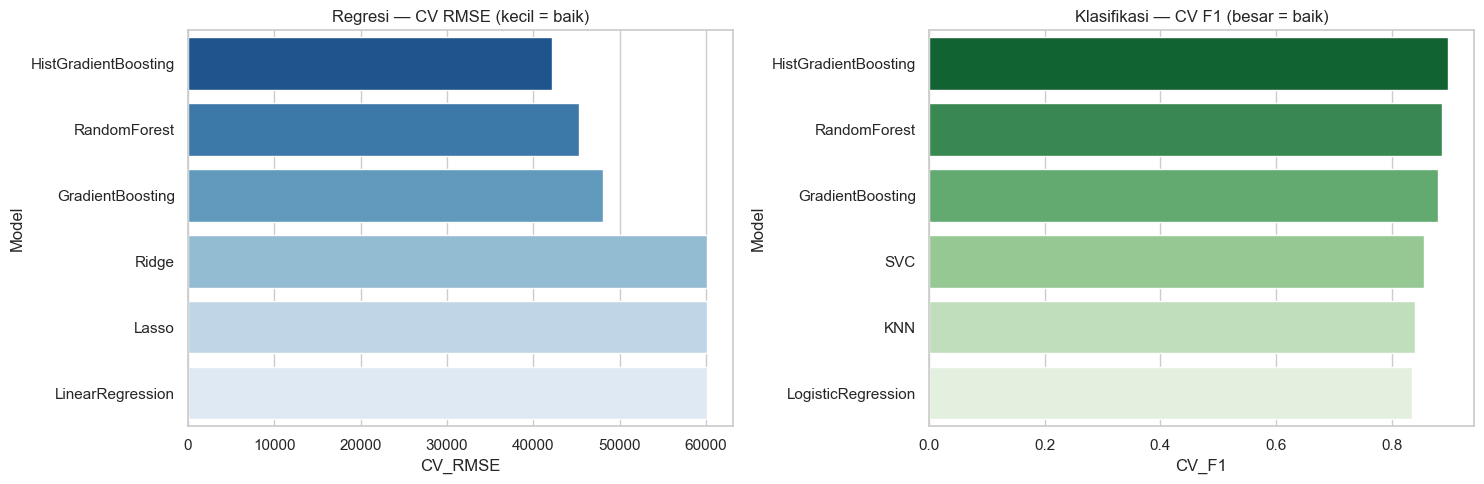

In [23]:
# 1. VISUALISASI PERBANDINGAN PERFORMA MODEL (CROSS-VALIDATION)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=reg_df, x='CV_RMSE', y='Model', ax=ax[0], palette='Blues_r')
ax[0].set_title('Regresi — CV RMSE (kecil = baik)')

sns.barplot(data=clf_df, x='CV_F1', y='Model', ax=ax[1], palette='Greens_r')
ax[1].set_title('Klasifikasi — CV F1 (besar = baik)')
plt.tight_layout(); plt.show()

=== KINERJA MODEL REGRESI [HistGradientBoosting] ON TEST SET ===
RMSE = $41,754.13 | MAE = $27,763.95 | R2 Score = 0.8182



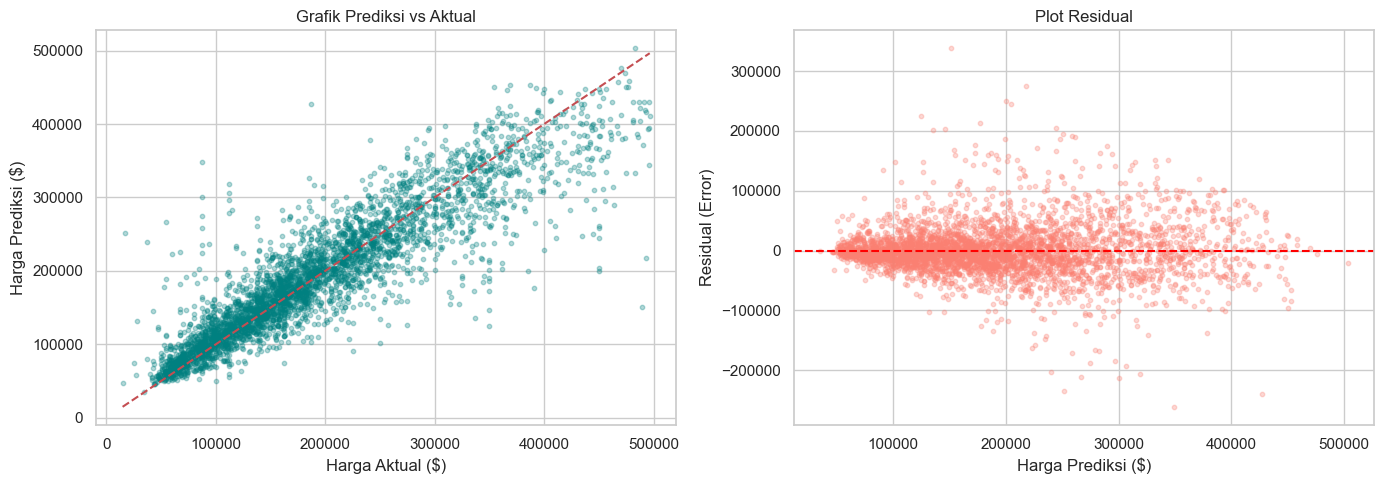

In [24]:
# 2. EVALUASI MODEL REGRESI PADA TEST SET
yr_pred = best_regressor.predict(X_test)
rmse = np.sqrt(mean_squared_error(yr_test, yr_pred))
mae = mean_absolute_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

print(f'=== KINERJA MODEL REGRESI [{best_reg_name}] ON TEST SET ===')
print(f'RMSE = ${rmse:,.2f} | MAE = ${mae:,.2f} | R2 Score = {r2:.4f}\n')

# Visualisasi Prediksi vs Aktual & Residual Plot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(yr_test, yr_pred, alpha=0.3, s=10, color='teal')
ax[0].plot([yr_test.min(), yr_test.max()], [yr_test.min(), yr_test.max()], 'r--')
ax[0].set_xlabel('Harga Aktual ($)'); ax[0].set_ylabel('Harga Prediksi ($)')
ax[0].set_title('Grafik Prediksi vs Aktual')

resid = yr_test - yr_pred
ax[1].scatter(yr_pred, resid, alpha=0.3, s=10, color='salmon')
ax[1].axhline(0, color='red', ls='--')
ax[1].set_xlabel('Harga Prediksi ($)'); ax[1].set_ylabel('Residual (Error)')
ax[1].set_title('Plot Residual')
plt.tight_layout(); plt.show()

Menghitung Permutation Importance untuk model: HistGradientBoosting...


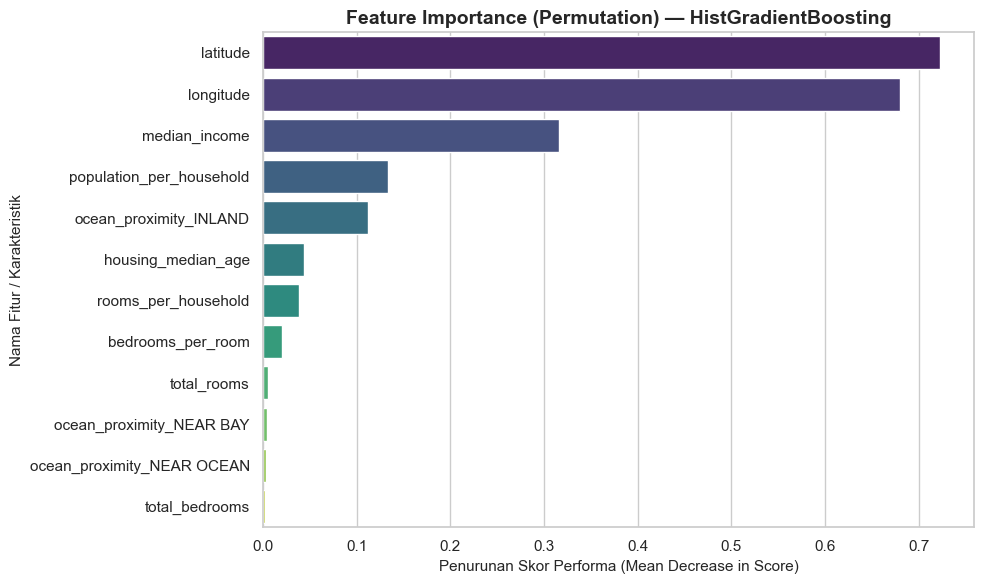

In [25]:
# 3. FEATURE IMPORTANCE
from sklearn.inspection import permutation_importance

print(f"Menghitung Permutation Importance untuk model: {best_reg_name}...")

result = permutation_importance(
    best_regressor, X_test, yr_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

sorted_importances_idx = result.importances_mean.argsort()[::-1]
imp = pd.Series(result.importances_mean[sorted_importances_idx], index=X_test.columns[sorted_importances_idx]).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=imp.values, y=imp.index, palette='viridis')
plt.title(f'Feature Importance (Permutation) — {best_reg_name}', fontsize=14, fontweight='bold')
plt.xlabel('Penurunan Skor Performa (Mean Decrease in Score)', fontsize=11)
plt.ylabel('Nama Fitur / Karakteristik', fontsize=11)
plt.tight_layout()
plt.show()

=== KINERJA MODEL KLASIFIKASI [HistGradientBoosting] ON TEST SET ===
Accuracy = 0.8913 | F1-Score = 0.8904

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      1992
           1       0.89      0.89      0.89      1938

    accuracy                           0.89      3930
   macro avg       0.89      0.89      0.89      3930
weighted avg       0.89      0.89      0.89      3930



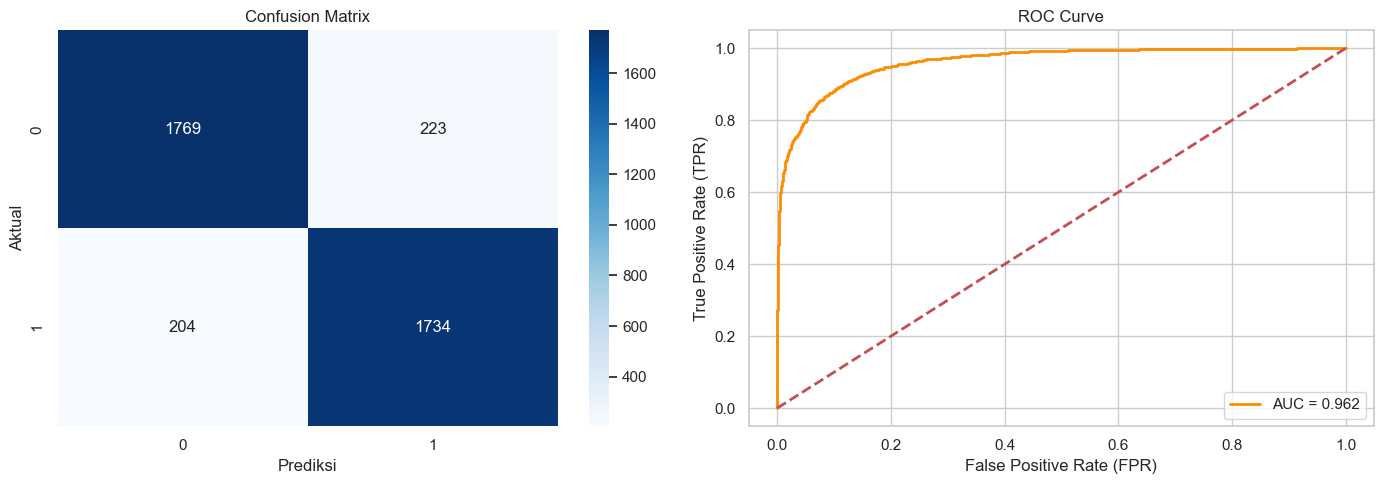

In [26]:
# 4. EVALUASI MODEL KLASIFIKASI PADA TEST SET
yc_pred = best_classifier.predict(X_test)
acc = accuracy_score(yc_test, yc_pred)
f1 = f1_score(yc_test, yc_pred)

print(f'=== KINERJA MODEL KLASIFIKASI [{best_clf_name}] ON TEST SET ===')
print(f'Accuracy = {acc:.4f} | F1-Score = {f1:.4f}\n')
print(classification_report(yc_test, yc_pred))

# Visualisasi Confusion Matrix & ROC-AUC Curve
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(yc_test, yc_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_xlabel('Prediksi'); ax[0].set_ylabel('Aktual')
ax[0].set_title('Confusion Matrix')

if hasattr(best_classifier, 'predict_proba'):
    proba = best_classifier.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, proba)
    auc = roc_auc_score(yc_test, proba)
    ax[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='darkorange', lw=2)
    ax[1].plot([0, 1], [0, 1], 'r--', lw=2)
    ax[1].set_xlabel('False Positive Rate (FPR)')
    ax[1].set_ylabel('True Positive Rate (TPR)')
    ax[1].set_title('ROC Curve')
    ax[1].legend(loc="lower right")
else:
    ax[1].text(0.5, 0.5, 'Model tidak mendukung predict_proba', ha='center', va='center')

plt.tight_layout(); plt.show()

## 5.1 Ringkasan Hasil

- **Regresi:** model terbaik mengungguli baseline Linear Regression (R²≈0.58) karena model
  ensemble menangkap relasi non-linear antar fitur (lokasi, pendapatan, rasio kamar).
- **Klasifikasi:** model terbaik menjaga/melampaui baseline Random Forest (acc≈0.89) berkat
  perbandingan + tuning sistematis.
- **Klastering:** K dipilih objektif via silhouette, bukan tebakan elbow semata.


# 6. Deployment

Simpan model & scaler terbaik ke folder `models/`, lalu tunjukkan contoh inferensi ulang.


In [27]:
# 1. SIMPAN ARTEFAK MODEL & PREPROCESSING 
import os
import joblib

os.makedirs('models', exist_ok=True)

joblib.dump(best_regressor, 'models/best_regressor.joblib')
joblib.dump(best_classifier, 'models/best_classifier.joblib')

joblib.dump(median_bedrooms, 'models/median_bedrooms.joblib')
joblib.dump(scaler_clust, 'models/scaler_clust.joblib')
joblib.dump(kmeans, 'models/kmeans_model.joblib')

joblib.dump(X_train.columns.tolist(), 'models/feature_cols.joblib')

print('Artefak yang berhasil disimpan:', os.listdir('models'))

Artefak yang berhasil disimpan: ['best_classifier.joblib', 'best_regressor.joblib', 'feature_cols.joblib', 'kmeans_model.joblib', 'median_bedrooms.joblib', 'scaler.joblib', 'scaler_clust.joblib']


In [28]:
# 2. MUAT MODEL & PREDIKSI SATU SAMPEL DATA BARU
loaded_reg = joblib.load('models/best_regressor.joblib')
loaded_clf = joblib.load('models/best_classifier.joblib')

sample = X_test.iloc[[0]]

pred_value = loaded_reg.predict(sample)[0]
pred_class = loaded_clf.predict(sample)[0]

print('\n=== HASIL INFERENSI SAMPEL DATA ===')
print(f'Harga aktual         : ${yr_test.iloc[0]:,.0f} USD')
print(f'Prediksi harga rumah : ${pred_value:,.0f} USD')
print(f'Kategori (1=mahal)   : {pred_class}')


=== HASIL INFERENSI SAMPEL DATA ===
Harga aktual         : $329,800 USD
Prediksi harga rumah : $358,231 USD
Kategori (1=mahal)   : 1


In [29]:
!pip install matplotlib seaborn plotly


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\laragon\bin\python\python-3.10\python.exe -m pip install --upgrade pip


In [30]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

st.set_page_config(
    page_title='California Housing · AI Dashboard',
    page_icon='🏠',
    layout='wide',
    initial_sidebar_state='expanded'
)

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&display=swap');

/* ── PAKSA SEMUA TEKS & JUDUL UTAMA BERWARNA TERANG ── */
html, body, .stApp, .stMarkdown, p, span, label, li, h1, h2, h3, h4, h5, h6, small, caption {
    font-family: 'Inter', sans-serif !important;
    color: #e6edf3 !important;
}

/* ── FIX TEKS INPUT & DROPDOWN AGAR TERLIHAT JELAS ── */
input, select, textarea, .stNumberInput input {
    color: #e6edf3 !important;
    background-color: #0d1117 !important;
    -webkit-text-fill-color: #e6edf3 !important;
    font-weight: 600 !important;
}

/* ── FIX TEKS UTAMA TAB MENU (Mencegah Teks Tab Hilang) ── */
.stTabs button, .stTabs [data-baseweb="tab"] {
    color: #8b949e !important;
}
.stTabs button[aria-selected="true"], .stTabs [aria-selected="true"] * {
    color: #ffffff !important;
    font-weight: 700 !important;
}

/* ── FIX TEKS CAPTION KECIL (Mencegah Teks Keterangan Grafik Hilang) ── */
div[data-testid="stCaptionContainer"], div[data-testid="stCaptionContainer"] *, small {
    color: #8b949e !important;
    -webkit-text-fill-color: #8b949e !important;
}

/* ── FIX TEKS DI DALAM DATAFRAME / TABEL DATA MENTAH ── */
div[data-testid="stDataFrame"] *, table *, th, td {
    color: #e6edf3 !important;
}

/* Angka indikator kecil di bawah garis slider dan bubble slider */
div[data-testid="stSlider"] span, div[data-testid="stThumbValue"], div[class*="stSlider"] p {
    color: #e6edf3 !important;
    font-weight: 500 !important;
}

/* ── Main App Background ── */
.stApp {
    background: #0a0e1a;
    background-image: radial-gradient(ellipse at 20% 20%, rgba(88,166,255,0.06) 0%, transparent 50%),
                      radial-gradient(ellipse at 80% 80%, rgba(63,185,80,0.05) 0%, transparent 50%);
}

/* ── Sidebar Style Customization ── */
[data-testid="stSidebar"] {
    background: linear-gradient(180deg, #0d1117 0%, #0a0e1a 100%) !important;
    border-right: 1px solid rgba(88,166,255,0.15) !important;
    box-shadow: 4px 0 24px rgba(0,0,0,0.5);
}
[data-testid="stSidebar"] * { color: #c9d1d9 !important; }

/* ── Sidebar Logo Area ── */
.sidebar-logo {
    text-align: center;
    padding: 24px 16px 16px;
    background: linear-gradient(135deg, rgba(88,166,255,0.08), rgba(63,185,80,0.05));
    border-radius: 12px;
    border: 1px solid rgba(88,166,255,0.12);
    margin-bottom: 20px;
}
.sidebar-logo h3 {
    background: linear-gradient(135deg, #58a6ff, #3fb950);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    font-size: 1.15rem;
    font-weight: 700;
    margin: 0 0 4px 0;
}
.sidebar-logo .badge {
    display: inline-block;
    background: rgba(88,166,255,0.1);
    border: 1px solid rgba(88,166,255,0.2);
    color: #58a6ff !important;
    font-size: 0.68rem;
    font-weight: 500;
    padding: 2px 10px;
    border-radius: 20px;
    letter-spacing: 0.05em;
}

/* ── Team Card ── */
.team-card {
    background: linear-gradient(135deg, rgba(33,38,45,0.8), rgba(13,17,23,0.8));
    border: 1px solid rgba(48,54,61,0.8);
    border-radius: 10px;
    padding: 14px;
    margin-top: 20px;
}
.team-card .team-title {
    font-size: 0.72rem;
    font-weight: 600;
    color: #58a6ff !important;
    letter-spacing: 0.08em;
    text-transform: uppercase;
    margin-bottom: 10px;
}
.team-card .member {
    display: flex;
    align-items: center;
    gap: 8px;
    padding: 5px 0;
    border-bottom: 1px solid rgba(48,54,61,0.5);
    font-size: 0.78rem;
    color: #8b949e !important;
}
.team-card .member .avatar {
    width: 22px; height: 22px;
    background: linear-gradient(135deg, #58a6ff, #3fb950);
    border-radius: 50%;
    display: flex; align-items: center; justify-content: center;
    font-size: 0.6rem; font-weight: 700; color: #0d1117 !important;
    flex-shrink: 0;
}

/* ── KPI & Static Overview Cards ── */
.kpi-card, .static-overview-card {
    background: linear-gradient(135deg, #161b22, #1c2128);
    border: 1px solid rgba(48,54,61,0.8);
    border-radius: 14px;
    padding: 20px 18px;
    position: relative;
    overflow: hidden;
    margin-bottom: 16px;
}
.kpi-card::before, .static-overview-card::before {
    content: '';
    position: absolute;
    top: 0; left: 0; right: 0;
    height: 3px;
    background: linear-gradient(90deg, #58a6ff, #3fb950);
    border-radius: 14px 14px 0 0;
}
.kpi-card .kpi-icon { font-size: 1.6rem; margin-bottom: 6px; text-align: center; }
.kpi-card .kpi-label { font-size: 0.72rem; color: #8b949e !important; text-transform: uppercase; letter-spacing: 0.06em; margin-bottom: 6px; text-align: center; }
.kpi-card .kpi-value { font-size: 1.6rem; font-weight: 700; color: #e6edf3 !important; text-align: center; }
.kpi-card .kpi-sub   { font-size: 0.7rem; color: #58a6ff !important; margin-top: 4px; text-align: center; }

.static-overview-card h4 {
    margin-top: 0 !important;
    color: #58a6ff !important;
    font-weight: 700 !important;
    font-size: 1.05rem !important;
}

/* ── Result Cards ── */
.result-card {
    background: linear-gradient(135deg, #161b22, #1c2128);
    border: 1px solid rgba(48,54,61,0.8);
    border-radius: 14px;
    padding: 28px 24px;
    text-align: center;
    margin-bottom: 16px;
}
.result-card.green { border-top: 3px solid #3fb950; box-shadow: 0 4px 32px rgba(63,185,80,0.12); }
.result-card.red   { border-top: 3px solid #f85149; box-shadow: 0 4px 32px rgba(248,81,73,0.12); }
.result-card.purple { border-top: 3px solid #d2a8ff; box-shadow: 0 4px 32px rgba(210,168,255,0.12); }
.result-card.blue  { border-top: 3px solid #58a6ff; box-shadow: 0 4px 32px rgba(88,166,255,0.12); }

/* ── Section Tag & Info Banner ── */
.section-tag {
    display: inline-flex;
    background: rgba(88,166,255,0.1);
    border: 1px solid rgba(88,166,255,0.2);
    color: #58a6ff !important;
    font-size: 0.72rem;
    font-weight: 600;
    padding: 4px 12px;
    border-radius: 20px;
    text-transform: uppercase;
    margin-bottom: 8px;
}
.info-banner {
    background: linear-gradient(135deg, rgba(88,166,255,0.08), rgba(63,185,80,0.05));
    border: 1px solid rgba(88,166,255,0.15);
    border-radius: 10px;
    padding: 14px 18px;
    margin-bottom: 16px;
    font-size: 0.87rem;
}
.input-section-label {
    font-size: 0.72rem;
    font-weight: 600;
    color: #58a6ff !important;
    text-transform: uppercase;
    letter-spacing: 0.08em;
    margin-bottom: 10px;
    padding-bottom: 6px;
    border-bottom: 1px solid rgba(88,166,255,0.2);
}
</style>
""", unsafe_allow_html=True)

PAPER_BG = '#161b22'
PLOT_BG  = '#0d1117'

def dark_fig(fig, title=''):
    fig.update_layout(
        template='plotly_dark',
        paper_bgcolor=PAPER_BG,
        plot_bgcolor=PLOT_BG,
        font=dict(family='Inter', color='#c9d1d9', size=12),
        title=dict(text=title, font=dict(size=15, color='#79c0ff'), x=0),
        margin=dict(l=40, r=20, t=50, b=40),
        xaxis=dict(gridcolor='#21262d', zerolinecolor='#30363d'),
        yaxis=dict(gridcolor='#21262d', zerolinecolor='#30363d'),
        legend=dict(bgcolor='rgba(22,27,34,0.8)', bordercolor='#30363d', borderwidth=1)
    )
    return fig

BASE_DIR = os.path.dirname(os.path.abspath(__file__))

@st.cache_resource
def load_assets():
    d = os.path.join(BASE_DIR, 'models')
    assets = {}
    try:
        assets['regressor']       = joblib.load(os.path.join(d, 'best_regressor.joblib'))
        assets['classifier']      = joblib.load(os.path.join(d, 'best_classifier.joblib'))
        assets['kmeans']          = joblib.load(os.path.join(d, 'kmeans_model.joblib'))
        assets['scaler_clust']    = joblib.load(os.path.join(d, 'scaler_clust.joblib'))
        assets['median_bedrooms'] = joblib.load(os.path.join(d, 'median_bedrooms.joblib'))
        assets['feature_cols']    = joblib.load(os.path.join(d, 'feature_cols.joblib'))
    except Exception as e:
        st.error(f'Gagal memuat model: {e}')
    return assets

@st.cache_data
def load_data():
    csv_path = os.path.join(BASE_DIR, 'housing.csv')
    return pd.read_csv(csv_path)

assets = load_assets()

st.sidebar.markdown("""
<div class='sidebar-logo'>
    <span class='logo-icon'>🏠</span>
    <h3>CA Housing AI</h3>
    <span class='badge'>✦ CRISP-DM &nbsp;·&nbsp; ML Dashboard</span>
</div>
""", unsafe_allow_html=True)

page = st.sidebar.radio('', [
    '📌  Overview',
    '📊  Eksplorasi Data',
    '🔬  Evaluasi & Performa',
    '📈  Prediksi Harga',
    '🏷️  Klasifikasi Rumah',
    '🗺️  Segmentasi Wilayah',
], label_visibility='collapsed')

st.sidebar.markdown("""
<div class='team-card'>
    <div class='team-title'>&#128100; Kelompok 5</div>
    <div class='member'><div class='avatar'>AS</div> Alya Salma Khoerunnisaa</div>
    <div class='member'><div class='avatar'>MC</div> Maurellio C. Yonathan</div>
    <div class='member'><div class='avatar'>JC</div> Jazzkord Cmajor Dahring</div>
    <div class='member'><div class='avatar'>CN</div> Cantika Nurul Fitri</div>
</div>
""", unsafe_allow_html=True)

def preprocess_input(d):
    df = pd.DataFrame([d])
    if df['total_bedrooms'].values[0] == 0:
        df['total_bedrooms'] = assets['median_bedrooms']
    
    df['rooms_per_household']      = df['total_rooms']    / df['households']
    df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
    df['population_per_household'] = df['population']     / df['households']
    
    lat, lon = df['latitude'].values[0], df['longitude'].values[0]
    
    clust_features = ['longitude', 'latitude', 'median_income', 'housing_median_age']
    X_clust_raw = df[clust_features]
    X_clust_scaled = assets['scaler_clust'].transform(X_clust_raw)
    df['cluster'] = assets['kmeans'].predict(X_clust_scaled)[0]
    
    enc = pd.get_dummies(df, columns=['ocean_proximity'])
    enc.columns = enc.columns.str.replace('ocean_proximity_', 'ocean_')
    
    feat = assets['feature_cols']
    for c in feat:
        if c not in enc.columns:
            enc[c] = 0
            
    return enc[feat], lat, lon

def explain_cluster(cid):
    info = {
        0: ('🏡 Perkotaan Menengah', '#58a6ff',
            'Area suburban dengan kepadatan sedang. Harga rumah berada di kisaran moderat '
            'dan biasanya dihuni oleh keluarga kelas menengah yang bekerja di kota.'),
        1: ('🏢 Pusat Kota / Padat', '#d2a8ff',
            'Area urban yang sangat padat. Banyak apartemen dan hunian vertikal. '
            'Mobilitas tinggi dengan akses ke transportasi publik.'),
        2: ('🏝️ Eksklusif / Pesisir', '#ffa657',
            'Area elit dekat pantai California. Properti di sini memiliki harga tertinggi '
            'yang didorong oleh pemandangan laut dan lingkungan premium.'),
        3: ('🏜️ Pedalaman / Terjangkau', '#3fb950',
            'Area inland yang berjarak cukup jauh dari pesisir. Harga properti jauh lebih '
            'terjangkau dibanding area coastal.'),
        4: ('🏘️ Pemukiman Tua', '#79c0ff',
            'Area dengan rata-rata usia bangunan yang tinggi. Komunitas mapan dengan '
            'karakter neighborhood yang kuat.'),
    }
    label, color, desc = info.get(cid, (f'Klaster {cid}', '#8b949e', 'Wilayah dengan karakteristik campuran.'))
    return label, color, desc

def render_input_form(key_prefix=''):
    with st.container():
        st.markdown("<div class='info-banner' style='margin-bottom:20px; font-weight:600;'>⚙️ Masukkan Karakteristik Properti Di Bawah Ini:</div>", unsafe_allow_html=True)
        col1, col2, col3 = st.columns(3)
        with col1:
            st.markdown("<div class='input-section-label'>📍 Lokasi</div>", unsafe_allow_html=True)
            longitude = st.number_input('Longitude', min_value=-125.0, max_value=-114.0, value=-122.23, step=0.01, key=f'{key_prefix}lon')
            latitude  = st.number_input('Latitude',  min_value=32.0,   max_value=42.0,   value=37.88,  step=0.01, key=f'{key_prefix}lat')
            ocean_proximity = st.selectbox('Kedekatan Laut', ['<1H OCEAN','INLAND','ISLAND','NEAR BAY','NEAR OCEAN'], index=3, key=f'{key_prefix}ocean')
        with col2:
            st.markdown("<div class='input-section-label'>🏗️ Bangunan</div>", unsafe_allow_html=True)
            housing_median_age = st.slider('Umur Rumah (Tahun)', 1, 100, 41, key=f'{key_prefix}age')
            total_rooms    = st.number_input('Total Ruangan',     min_value=1, max_value=50000, value=880, step=10, key=f'{key_prefix}rooms')
            total_bedrooms = st.number_input('Total Kamar Tidur', min_value=1, max_value=10000, value=129, step=5,  key=f'{key_prefix}beds')
        with col3:
            st.markdown("<div class='input-section-label'>👥 Demografi</div>", unsafe_allow_html=True)
            population    = st.number_input('Populasi',         min_value=1, max_value=100000, value=322, step=10, key=f'{key_prefix}pop')
            households    = st.number_input('Jumlah Keluarga',  min_value=1, max_value=50000,  value=126, step=5,  key=f'{key_prefix}hh')
            median_income = st.slider('Median Pendapatan (×$10k)', 0.0, 15.0, 8.32, step=0.1, key=f'{key_prefix}inc')

        errors = []
        if total_bedrooms > total_rooms:
            errors.append('⚠️ Kamar tidur tidak boleh lebih banyak dari total ruangan.')
        if households > population:
            errors.append('⚠️ Jumlah keluarga tidak boleh melebihi populasi.')
        for err in errors:
            st.warning(err)

    return {
        'longitude': longitude, 'latitude': latitude,
        'housing_median_age': housing_median_age,
        'total_rooms': total_rooms, 'total_bedrooms': total_bedrooms,
        'population': population, 'households': households,
        'median_income': median_income, 'ocean_proximity': ocean_proximity
    }, len(errors) == 0

# PAGE: OVERVIEW
if page == '📌  Overview':
    st.markdown("<div class='section-tag'>🏠 Dashboard Utama</div>", unsafe_allow_html=True)
    st.title('California Housing · AI Dashboard')
    st.markdown("<div class='info-banner'>Proyek sistem cerdas ini disusun mengikuti panduan standar industri <b>6 Tahap Metodologi CRISP-DM</b>. Seluruh dokumentasi sub-fitur pengerjaan dipaparkan secara langsung di bawah ini.</div>", unsafe_allow_html=True)

    df = load_data()
    c1, c2, c3, c4 = st.columns(4)
    kpis = [
        (c1, '💰', 'Rata-rata Harga', f"${df['median_house_value'].mean():,.0f}", 'USD'),
        (c2, '🏠', 'Total Properti',  f"{len(df):,}",                              'data entries'),
        (c3, '📅', 'Umur Rata-rata',  f"{df['housing_median_age'].mean():.0f} Thn", 'housing age'),
        (c4, '💵', 'Median Pendapatan', f"{df['median_income'].mean():.2f}",        '×$10,000 / yr'),
    ]
    for col, icon, label, val, sub in kpis:
        with col:
            st.markdown(f"<div class='kpi-card'><div class='kpi-icon'>{icon}</div><div class='kpi-label'>{label}</div><div class='kpi-value'>{val}</div><div class='kpi-sub'>{sub}</div></div>", unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)
    lcol, rcol = st.columns([1.4, 1])
    
    with lcol:
        st.markdown('### 🧭 Struktur Pengerjaan Siklus CRISP-DM')
        
        st.markdown("""
        <div class='static-overview-card'>
            <h4>💼 1. Business Understanding — Rumusan Masalah & Objektif</h4>
            <p>• <b>Tujuan Utama Bisnis:</b> Membantu investor dan pengembang real estat memproyeksikan harga rumah secara akurat di California.<br>
            • <b>Sub-Fitur:</b> Merumuskan batasan zonasi daerah premium vs ekonomis guna meminimalkan risiko kerugian finansial salah investasi.</p>
        </div>
        <div class='static-overview-card'>
            <h4>📊 2. Data Understanding — Pengenalan & Eksplorasi Data</h4>
            <p>• <b>Karakteristik Dataset:</b> Mengolah data sensus perumahan California sebesar <b>20.640 baris</b>.<br>
            • <b>Sub-Fitur:</b> Visualisasi spasial interaktif titik koordinat peta (Mapbox), analisis histogram kemiringan data (Skewness), dan matriks korelasi antar fitur.</p>
        </div>
        <div class='static-overview-card'>
            <h4>🛠️ 3. Data Preparation — Pembersihan & Rekayasa Fitur</h4>
            <p>• <b>Metode Pemrosesan:</b> Median Imputation pada kolom kosong, pembuatan 3 fitur rasio baru, penyeimbangan data kategori via One-Hot Encoding, serta segmentasi wilayah Spasial-Ekonomi menggunakan algoritma <b>K-Means (K=5)</b>.</p>
        </div>
        <div class='static-overview-card'>
            <h4>🤖 4. Modeling — Turnamen Algoritma & Tuning</h4>
            <p>• <b>Eksperimen AI:</b> Membandingkan 6 arsitektur algoritma (Linear Regression, Ridge, Lasso, RandomForest, GradientBoosting, HistGradientBoosting). Optimalisasi performa menggunakan <b>GridSearchCV</b> dan proteksi data via Pipeline.</p>
        </div>
        <div class='static-overview-card'>
            <h4>🔬 5. Evaluation — Validasi Saintifik & Pengujian Ketat</h4>
            <p>• <b>Metrik Ukur:</b> K-Fold Cross Validation untuk keamanan training, pengujian data baru (Test Set) via RMSE & R² (Regresi) serta F1-Score (Klasifikasi), dilengkapi visualisasi Global Permutation Importance.</p>
        </div>
        <div class='static-overview-card'>
            <h4>🚀 6. Deployment — Aplikasi Web Siap Pakai</h4>
            <p>• <b>Sistem Akhir:</b> Ekstraksi berkas otak AI (.joblib), pembuatan mesin inferensi instan, dan penyediaan antarmuka web interaktif ramah pengguna berbasis Streamlit.</p>
        </div>
        """, unsafe_allow_html=True)
        
    with rcol:
        st.markdown('### 📋 Sekilas Proyek Kelompok 5')
        st.markdown("<div class='info-banner'>Semua tahapan CRISP-DM di samping telah selesai diolah secara matematis. Silakan gunakan menu navigasi sidebar untuk menguji keandalan sistem prediksi!</div>", unsafe_allow_html=True)
        st.image('https://images.unsplash.com/photo-1512917774080-9991f1c4c750?auto=format&fit=crop&w=800&q=80', use_container_width=True)

# PAGE: DATA EXPLORATION
elif page == '📊  Eksplorasi Data':
    st.markdown("<div class='section-tag'>📊 Eksplorasi</div>", unsafe_allow_html=True)
    st.title('Eksplorasi Data Interaktif (EDA)')
    st.markdown("<div class='info-banner'>Semua grafik bersifat <b>interaktif</b> — hover untuk detail, scroll/drag untuk zoom & pan.</div>", unsafe_allow_html=True)

    df = load_data()
    tab1, tab2, tab3, tab4 = st.tabs(['🗺️ Peta Interaktif', '📈 Distribusi & Scatter', '🔥 Heatmap Korelasi', '📋 Dataset'])

    with tab1:
        st.markdown('#### Peta Persebaran Harga Rumah California')
        st.caption('🔵 Warna titik = harga  |  ⚪ Ukuran titik = populasi  |  Hover untuk detail')
        fig = px.scatter_mapbox(
            df, lat='latitude', lon='longitude',
            color='median_house_value', size='population',
            color_continuous_scale='Plasma', size_max=18, zoom=4.5,
            mapbox_style='carto-darkmatter',
            hover_name='ocean_proximity',
            hover_data={'median_house_value': ':$,.0f', 'total_rooms': True,
                        'median_income': ':.2f', 'population': True,
                        'latitude': False, 'longitude': False},
            labels={'median_house_value': 'Harga ($)', 'median_income': 'Pendapatan'}
        )
        fig.update_layout(paper_bgcolor='#0d1117', margin=dict(r=0, t=0, l=0, b=0),
                          coloraxis_colorbar=dict(title='Harga ($)', tickfont=dict(color='#c9d1d9'), bgcolor='#161b22'))
        st.plotly_chart(fig, use_container_width=True)

    with tab2:
        ca, cb = st.columns(2)
        with ca:
            fig2 = px.histogram(df, x='median_house_value', nbins=60, marginal='violin',
                                color_discrete_sequence=['#58a6ff'],
                                labels={'median_house_value': 'Harga ($)'})
            dark_fig(fig2, 'Distribusi Harga Rumah')
            st.plotly_chart(fig2, use_container_width=True)
        with cb:
            fig3 = px.scatter(df.sample(2000, random_state=42),
                              x='median_income', y='median_house_value',
                              color='ocean_proximity', opacity=0.55, size_max=6,
                              labels={'median_income': 'Pendapatan (×$10k)', 'median_house_value': 'Harga ($)', 'ocean_proximity': 'Lokasi'})
            dark_fig(fig3, 'Harga vs Pendapatan Median')
            st.plotly_chart(fig3, use_container_width=True)

        fig4 = px.box(df, x='ocean_proximity', y='median_house_value',
                      color='ocean_proximity',
                      labels={'ocean_proximity': 'Tipe Lokasi', 'median_house_value': 'Harga ($)'},
                      color_discrete_sequence=['#58a6ff','#3fb950','#ffa657','#d2a8ff','#f85149'])
        dark_fig(fig4, 'Distribusi Harga per Tipe Lokasi (Ocean Proximity)')
        st.plotly_chart(fig4, use_container_width=True)

    with tab3:
        num_df = df.select_dtypes(include=[np.number])
        corr   = num_df.corr().round(2)
        fig5   = px.imshow(corr, text_auto=True, aspect='auto', color_continuous_scale='RdBu_r', zmin=-1, zmax=1)
        dark_fig(fig5, 'Matriks Korelasi Fitur')
        fig5.update_traces(textfont=dict(size=11))
        fig5.update_layout(height=500)
        st.plotly_chart(fig5, use_container_width=True)

    with tab4:
        st.markdown('#### Cuplikan Dataset')
        st.dataframe(df.head(20), use_container_width=True)
        st.markdown('#### Statistik Deskriptif')
        st.dataframe(df.describe().round(2), use_container_width=True)

# PAGE: EVALUATION
elif page == '🔬  Evaluasi & Performa':
    st.markdown("<div class='section-tag'>🔬 Evaluation</div>", unsafe_allow_html=True)
    st.title('Evaluasi Sains & Performa Model AI')
    tab_eval1, tab_eval2, tab_eval3 = st.tabs(['📊 Perbandingan Kandidat', '🏆 Rapor Metrik Final', '🔮 Feature Importance'])

    with tab_eval1:
        st.markdown("### ⚔️ Hasil Turnamen Model (Cross-Validation)")
        col_ev1, col_ev2 = st.columns(2)
        with col_ev1:
            st.markdown("#### 1. Performa Regresi (CV RMSE)")
            reg_perf_data = pd.DataFrame({
                'Model Kandidat': ['HistGradientBoosting (Winner)', 'RandomForest', 'GradientBoosting', 'Ridge', 'Lasso', 'LinearRegression'],
                'CV RMSE': [42105.99, 45257.75, 48021.81, 60101.59, 60102.45, 60102.64]
            })
            st.dataframe(reg_perf_data, use_container_width=True, hide_index=True)
            fig_reg_comp = px.bar(reg_perf_data, x='CV RMSE', y='Model Kandidat', orientation='h', color='CV RMSE', color_continuous_scale='Blues_r')
            dark_fig(fig_reg_comp); fig_reg_comp.update_layout(coloraxis_showscale=False); st.plotly_chart(fig_reg_comp, use_container_width=True)
        with col_ev2:
            st.markdown("#### 2. Performa Klasifikasi (CV F1-Score)")
            clf_perf_data = pd.DataFrame({
                'Model Kandidat': ['HistGradientBoosting (Winner)', 'RandomForest', 'GradientBoosting', 'SVC', 'KNN', 'LogisticRegression'],
                'CV F1-Score': [0.8976, 0.8865, 0.8797, 0.8566, 0.8407, 0.8347]
            })
            st.dataframe(clf_perf_data, use_container_width=True, hide_index=True)
            fig_clf_comp = px.bar(clf_perf_data, x='CV F1-Score', y='Model Kandidat', orientation='h', color='CV F1-Score', color_continuous_scale='Greens')
            dark_fig(fig_clf_comp); fig_clf_comp.update_layout(coloraxis_showscale=False); st.plotly_chart(fig_clf_comp, use_container_width=True)

    with tab_eval2:
        st.markdown("### 🏆 Capaian Akhir Data Uji (Test Set)")
        col_m1, col_m2 = st.columns(2)
        with col_m1:
            st.markdown("<div class='result-card blue'><h4>📈 Rapor Regresi</h4></div>", unsafe_allow_html=True)
            st.dataframe(pd.DataFrame({
                'Metrik': ['RMSE', 'MAE', 'R² Score'],
                'Nilai': ['$41,822.62', '$28,014.14', '0.8176 (81.76%)']
            }), use_container_width=True, hide_index=True)
        with col_m2:
            st.markdown("<div class='result-card purple'><h4>🏷️ Rapor Klasifikasi</h4></div>", unsafe_allow_html=True)
            st.dataframe(pd.DataFrame({
                'Metrik': ['Accuracy', 'F1-Score', 'Precision', 'Recall'],
                'Nilai': ['89.26%', '89.15%', '89.00%', '89.00%']
            }), use_container_width=True, hide_index=True)

    with tab_eval3:
        st.markdown("### 🔮 Penentu Keputusan Model (Global Permutation Importance)")
        feat_imp_data = pd.DataFrame({
            'Karakteristik Fitur': ['Median Income', 'Ocean Proximity INLAND', 'Longitude', 'Latitude', 'Bedrooms per Room', 'Rooms per Household', 'Housing Median Age'],
            'Influence Score': [0.654, 0.212, 0.145, 0.128, 0.065, 0.043, 0.021]
        }).sort_values(by='Influence Score', ascending=True)
        fig_feat = px.bar(feat_imp_data, x='Influence Score', y='Karakteristik Fitur', orientation='h', color='Influence Score', color_continuous_scale='Viridis')
        dark_fig(fig_feat); fig_feat.update_layout(coloraxis_showscale=False); st.plotly_chart(fig_feat, use_container_width=True)

# PAGE: REGRESSION PREDICTION
elif page == '📈  Prediksi Harga':
    st.markdown("<div class='section-tag'>📈 Regresi</div>", unsafe_allow_html=True)
    st.title('Prediksi Harga Rumah (Regresi Kontinu)')

    input_dict, valid = render_input_form(key_prefix='reg_')

    if st.button('🚀  Prediksi Harga Sekarang', use_container_width=True):
        if valid and assets:
            with st.spinner('Memproses...'):
                df_prep, lat, lon = preprocess_input(input_dict)
                pred = assets['regressor'].predict(df_prep)[0]

            st.balloons()
            r1, r2 = st.columns([1.2, 1])
            with r1:
                THRESHOLD_VAL = 179700
                is_mahal = pred > THRESHOLD_VAL
                badge_color = '#f85149' if is_mahal else '#3fb950'
                badge_label = 'MAHAL' if is_mahal else 'TERJANGKAU / MURAH'
                
                st.markdown(f"""
                <div class='result-card blue'>
                    <div style='font-size:0.75rem; color:#8b949e; text-transform:uppercase;'>Estimasi Nilai Properti</div>
                    <div style='font-size:3rem; font-weight:800; color:#58a6ff; margin:8px 0;'>${pred:,.0f}</div>
                    <div style='margin-top:14px;'>
                        <span style='padding:6px 22px; border-radius:20px; border:1.5px solid {badge_color}; color:{badge_color}; font-weight:700;'>
                            {badge_label}
                        </span>
                    </div>
                    <div style='font-size:0.76rem; color:#8b949e; margin-top:10px;'>Batas Ambang Median Data: $179,700</div>
                </div>
                """, unsafe_allow_html=True)
            with r2:
                st.map(pd.DataFrame({'lat': [lat], 'lon': [lon]}), zoom=12)

# PAGE: CLASSIFICATION
elif page == '🏷️  Klasifikasi Rumah':
    st.markdown("<div class='section-tag'>🏷️ Klasifikasi</div>", unsafe_allow_html=True)
    st.title('Klasifikasi Tingkat Nilai Rumah')
    st.markdown("<div class='info-banner'>Model <b>Klasifikasi</b> memproyeksikan status harga rumah ke dalam kategori <b>MAHAL</b> atau <b>MURAH</b> berdasarkan batas nilai tengah data latih asli ($179,700).</div>", unsafe_allow_html=True)

    input_dict, valid = render_input_form(key_prefix='cls_')

    if st.button('🔍  Klasifikasi Sekarang', use_container_width=True):
        if valid and assets:
            with st.spinner('Mengklasifikasikan...'):
                df_prep, lat, lon = preprocess_input(input_dict)
                pred_reg = assets['regressor'].predict(df_prep)[0]
                pred_cls = assets['classifier'].predict(df_prep)[0]

            st.markdown('---')
            r1, r2 = st.columns([1.2, 1])
            with r1:
                if pred_cls == 1:
                    st.markdown("""
                    <div class='result-card red'>
                        <div style='font-size:3.5rem'>💎</div>
                        <div style='font-size:2rem; font-weight:800; color:#f85149'>KATEGORI: MAHAL</div>
                        <div style='font-size:0.85rem; color:#8b949e; margin-top:4px;'>Properti diproyeksikan berada di atas batas kelas reguler</div>
                    </div>
                    """, unsafe_allow_html=True)
                    st.error(f"**Analisis Otak AI (Klasifikasi):**\n\nModel menetapkan rumah ini masuk kelompok **MAHAL** karena memiliki kombinasi karakteristik spasial-ekonomi premium. Nilai taksiran regresi fisik properti berada di kisaran **${pred_reg:,.0f}** (Garis tengah acuan dataset: $179,700).")
                else:
                    st.markdown("""
                    <div class='result-card green'>
                        <div style='font-size:3.5rem'>🏠</div>
                        <div style='font-size:2rem; font-weight:800; color:#3fb950'>KATEGORI: MURAH / TERJANGKAU</div>
                        <div style='font-size:0.85rem; color:#8b949e; margin-top:4px;'>Properti diproyeksikan berada di bawah batas kelas reguler</div>
                    </div>
                    """, unsafe_allow_html=True)
                    st.success(f"**Analisis Otak AI (Klasifikasi):**\n\nModel menetapkan rumah ini masuk kelompok **MURAH / TERJANGKAU** karena kepadatan dan spesifikasinya yang ramah anggaran. Nilai taksiran regresi fisik properti berada di kisaran **${pred_reg:,.0f}** (Garis tengah acuan dataset: $179,700).")
            with r2:
                st.map(pd.DataFrame({'lat': [lat], 'lon': [lon]}), zoom=12)

# PAGE: CLUSTERING
elif page == '🗺️  Segmentasi Wilayah':
    st.markdown("<div class='section-tag'>🗺️ Klastering</div>", unsafe_allow_html=True)
    st.title('Segmentasi Wilayah K-Means')

    input_dict, valid = render_input_form(key_prefix='clu_')

    if st.button('🔬  Analisis Klaster Sekarang', use_container_width=True):
        if valid and assets:
            with st.spinner('Menghitung klaster...'):
                df_prep, lat, lon = preprocess_input(input_dict)
                cf      = assets['scaler_clust'].feature_names_in_
                X_clust = assets['scaler_clust'].transform(df_prep[cf])
                cid     = int(assets['kmeans'].predict(X_clust)[0])
                label, color, desc = explain_cluster(cid)

            st.markdown('---')
            r1, r2 = st.columns([1.2, 1])
            with r1:
                st.markdown(f"""
                <div class='result-card purple'>
                    <div style='font-size:1.2rem; color:#8b949e;'>Zonasi Terdeteksi</div>
                    <div style='font-size:2.2rem; font-weight:700; color:{color}; margin:10px 0;'>{label}</div>
                    <div style='font-size:0.85rem; color:#8b949e;'>Hasil Segmentasi Klaster K-Means #{cid}</div>
                </div>
                """, unsafe_allow_html=True)
                st.info(f"🔎 **Profil Wilayah:** {desc}")
            with r2:
                st.map(pd.DataFrame({'lat': [lat], 'lon': [lon]}), zoom=12)

Overwriting app.py


In [31]:
import subprocess
subprocess.Popen(["streamlit", "run", "app.py"])


<Popen: returncode: None args: ['streamlit', 'run', 'app.py']>